In [ ]:
import pandas as pd
import numpy as np

# Load the data

In [ ]:
df_original = pd.read_csv('/content/beer_reviews_clean_100k.csv')
df_original.head()

,beer_name,beer_id,brewer_id,beer_abv,style,review_profileName,review_time,text,rating_overall,rating_taste,rating_appearance,rating_palate,rating_aroma
0,Sausa Weizen,47986,10325,5.0,Hefeweizen,stcules,1234817823,A lot of foam. But a lot.\tIn the smell some b...,1.5,1.5,2.5,1.5,2.0
1,Red Moon,48213,10325,6.2,English Strong Ale,stcules,1235915097,"Dark red color, light beige foam, average.\tIn...",3.0,3.0,3.0,3.0,2.5
2,Black Horse Black Beer,48215,10325,6.5,Foreign / Export Stout,stcules,1235916604,"Almost totally black. Beige foam, quite compac...",3.0,3.0,3.0,3.0,2.5
3,Sausa Pils,47969,10325,5.0,German Pilsener,stcules,1234725145,"Golden yellow color. White, compact foam, quit...",3.0,3.0,3.5,2.5,3.0
4,Cauldron DIPA,64883,1075,7.7,American Double / Imperial IPA,johnmichaelsen,1293735206,"According to the website, the style for the Ca...",4.0,4.5,4.0,4.0,4.5


The overall rating is avg(mean) of other 4 ratings -> rating_taste,	rating_appearance,rating_palate, rating_aroma

# create target variable on the basis of rating

In [ ]:
import re

# 1. Map the numeric ratings to Sentiment Labels (Target Variable)
def label_sentiment(rating):
    if rating >= 4.0:
        return 'Positive'
    elif rating <= 2.5:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
df_original['sentiment'] = df_original['rating_overall'].apply(label_sentiment)

In [ ]:
df_original.head()

,beer_name,beer_id,brewer_id,beer_abv,style,review_profileName,review_time,text,rating_overall,rating_taste,rating_appearance,rating_palate,rating_aroma,sentiment
0,Sausa Weizen,47986,10325,5.0,Hefeweizen,stcules,1234817823,A lot of foam. But a lot.\tIn the smell some b...,1.5,1.5,2.5,1.5,2.0,Negative
1,Red Moon,48213,10325,6.2,English Strong Ale,stcules,1235915097,"Dark red color, light beige foam, average.\tIn...",3.0,3.0,3.0,3.0,2.5,Neutral
2,Black Horse Black Beer,48215,10325,6.5,Foreign / Export Stout,stcules,1235916604,"Almost totally black. Beige foam, quite compac...",3.0,3.0,3.0,3.0,2.5,Neutral
3,Sausa Pils,47969,10325,5.0,German Pilsener,stcules,1234725145,"Golden yellow color. White, compact foam, quit...",3.0,3.0,3.5,2.5,3.0,Neutral
4,Cauldron DIPA,64883,1075,7.7,American Double / Imperial IPA,johnmichaelsen,1293735206,"According to the website, the style for the Ca...",4.0,4.5,4.0,4.0,4.5,Positive


In [ ]:
df_new = df_original.drop(['beer_name', 'beer_id',	'brewer_id', 'review_profileName',	'review_time'], axis =1)

In [ ]:
df_new.head()

,beer_abv,style,text,rating_overall,rating_taste,rating_appearance,rating_palate,rating_aroma,sentiment
0,5.0,Hefeweizen,A lot of foam. But a lot.\tIn the smell some b...,1.5,1.5,2.5,1.5,2.0,Negative
1,6.2,English Strong Ale,"Dark red color, light beige foam, average.\tIn...",3.0,3.0,3.0,3.0,2.5,Neutral
2,6.5,Foreign / Export Stout,"Almost totally black. Beige foam, quite compac...",3.0,3.0,3.0,3.0,2.5,Neutral
3,5.0,German Pilsener,"Golden yellow color. White, compact foam, quit...",3.0,3.0,3.5,2.5,3.0,Neutral
4,7.7,American Double / Imperial IPA,"According to the website, the style for the Ca...",4.0,4.5,4.0,4.0,4.5,Positive


# Basic preprocessing and text preparation

In [ ]:
df_text = df_new[['text']].copy()
df_text.head()

,text
0,A lot of foam. But a lot.\tIn the smell some b...
1,"Dark red color, light beige foam, average.\tIn..."
2,"Almost totally black. Beige foam, quite compac..."
3,"Golden yellow color. White, compact foam, quit..."
4,"According to the website, the style for the Ca..."


In [ ]:
print(df_text.shape)
print(df_text.isna().sum())

(100000, 1)
text    0
dtype: int64


In [ ]:
df_text['text'][1]

'Dark red color, light beige foam, average.\tIn the smell malt and caramel, not really light.\tAgain malt and caramel in the taste, not bad in the end.\tMaybe a note of honey in teh back, and a light fruitiness.\tAverage body.\tIn the aftertaste a light bitterness, with the malt and red fruit.\tNothing exceptional, but not bad, drinkable beer.'

## Clean the raw text (remove \t, \n, extra spaces, and lowercase it)

In [ ]:
def clean_raw_text(text):
    text = str(text) # Ensure it's a string
    text = re.sub(r'\s+', ' ', text) # Replaces tabs/newlines with a single space
    return text.strip().lower()

In [ ]:
df_new['clean_text'] = df_new['text'].apply(clean_raw_text)

print("Labels generated and text cleaned!")
# display(df[['clean_text', 'sentiment']].head())
display(df_new.head())

Labels generated and text cleaned!


,beer_abv,style,text,rating_overall,rating_taste,rating_appearance,rating_palate,rating_aroma,sentiment,clean_text
0,5.0,Hefeweizen,A lot of foam. But a lot.\tIn the smell some b...,1.5,1.5,2.5,1.5,2.0,Negative,a lot of foam. but a lot. in the smell some ba...
1,6.2,English Strong Ale,"Dark red color, light beige foam, average.\tIn...",3.0,3.0,3.0,3.0,2.5,Neutral,"dark red color, light beige foam, average. in ..."
2,6.5,Foreign / Export Stout,"Almost totally black. Beige foam, quite compac...",3.0,3.0,3.0,3.0,2.5,Neutral,"almost totally black. beige foam, quite compac..."
3,5.0,German Pilsener,"Golden yellow color. White, compact foam, quit...",3.0,3.0,3.5,2.5,3.0,Neutral,"golden yellow color. white, compact foam, quit..."
4,7.7,American Double / Imperial IPA,"According to the website, the style for the Ca...",4.0,4.5,4.0,4.0,4.5,Positive,"according to the website, the style for the ca..."


In [ ]:
df_new['clean_text'][1]

'dark red color, light beige foam, average. in the smell malt and caramel, not really light. again malt and caramel in the taste, not bad in the end. maybe a note of honey in teh back, and a light fruitiness. average body. in the aftertaste a light bitterness, with the malt and red fruit. nothing exceptional, but not bad, drinkable beer.'

# Japanese conversion code

In [ ]:
# # 1. Install Japanese processing libraries and deep-translator
# !pip install deep-translator spacy[japanese]
# !python -m spacy download ja_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/ja_core_news_sm-3.8.0/ja_core_news_sm-3.8.0-py3-none-any.whl (12.1 MB)
✔ Download and installation successful
You can now load the package via spacy.load('ja_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# import pandas as pd
# from deep_translator import GoogleTranslator
# from tqdm import tqdm

# # Let's take a sample of 500 rows to turn into Japanese reviews
# ja_sample = df_new.sample(n=500, random_state=42).copy()

# print("Translating a slice of data into Japanese to simulate global corporate text...")
# translated_texts = []

# # Loop with a progress bar
# for text in tqdm(ja_sample['clean_text']):
#     try:
#         # Translate English review to Japanese
#         translated = GoogleTranslator(source='en', target='ja').translate(text)
#         translated_texts.append(translated)
#     except Exception as e:
#         # Fallback if a specific line fails
#         translated_texts.append("このビールは美味しいです。")

# ja_sample['clean_text'] = translated_texts
# ja_sample['language'] = 'ja'

# # Mark the rest of the dataframe as English
# df['language'] = 'en'
# # Remove the rows we sampled so there is no overlap
# df_remaining = df.drop(ja_sample.index)

# # Combine them back together into your new Global Dataset!
# global_df = pd.concat([df_remaining, ja_sample], ignore_index=True)

# print("\n✅ Multilingual Dataset Created!")
# print(global_df['language'].value_counts())

Translating a slice of data into Japanese to simulate global corporate text...


100%|██████████| 500/500 [01:46<00:00,  4.70it/s]


✅ Multilingual Dataset Created!
language
en    99500
ja      500
Name: count, dtype: int64


# Advance preprocessing

In [ ]:
import spacy

# 1. Isolate the English data based on your translation split
df_en = df_new.copy()
print(f"Processing {len(df_en)} English reviews...")

# 2. Load spaCy (Disabling NER and Parser to make it run 10x faster)
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

# 3. Define the optimized batch-processing function
def spacy_preprocess_en(texts):
    processed_texts = []
    # nlp.pipe processes text in massive batches, utilizing Colab's RAM efficiently
    for doc in nlp.pipe(texts, batch_size=1000, n_process=-1):
        # This is where the magic happens:
        # token.is_alpha automatically drops all commas, periods, and numbers!
        # not token.is_stop drops words like "is", "the", "at"
        tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
        processed_texts.append(" ".join(tokens))
    return processed_texts

print("Starting spaCy pipeline - 100k records")
df_en['spacy_text'] = spacy_preprocess_en(df_en['clean_text'])

print("spaCy Processing Complete!")

Processing 100000 English reviews...
Starting spaCy pipeline - 100k records
spaCy Processing Complete!


saving the spacy data so don't have to run it for so long and wait for the output

In [ ]:
from google.colab import files

# 1. Export DataFrame to CSV
df_en.to_csv('spacy_processed_data.csv', index=False)

# 2. Download the CSV to your local machine
files.download('spacy_processed_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_en['spacy_text'][0]

'lot foam lot smell banana lactic tart good start dark orange color lively carbonation visible foam tend lactic sourness taste yeast banana'

In [ ]:
# Let's compare the original cleaned text with the final machine-ready text
display(df_en.head())

,beer_abv,style,text,rating_overall,rating_taste,rating_appearance,rating_palate,rating_aroma,sentiment,clean_text,spacy_text
0,5.0,Hefeweizen,A lot of foam. But a lot.\tIn the smell some b...,1.5,1.5,2.5,1.5,2.0,Negative,a lot of foam. but a lot. in the smell some ba...,lot foam lot smell banana lactic tart good sta...
1,6.2,English Strong Ale,"Dark red color, light beige foam, average.\tIn...",3.0,3.0,3.0,3.0,2.5,Neutral,"dark red color, light beige foam, average. in ...",dark red color light beige foam average smell ...
2,6.5,Foreign / Export Stout,"Almost totally black. Beige foam, quite compac...",3.0,3.0,3.0,3.0,2.5,Neutral,"almost totally black. beige foam, quite compac...",totally black beige foam compact bad light sme...
3,5.0,German Pilsener,"Golden yellow color. White, compact foam, quit...",3.0,3.0,3.5,2.5,3.0,Neutral,"golden yellow color. white, compact foam, quit...",golden yellow color white compact foam creamy ...
4,7.7,American Double / Imperial IPA,"According to the website, the style for the Ca...",4.0,4.5,4.0,4.0,4.5,Positive,"according to the website, the style for the ca...",accord website style caldera cauldron change y...


# Directly importing spacy and modelling it

In [ ]:
df_en = pd.read_csv('/content/spacy_processed_data.csv')

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X = df_en['spacy_text'].fillna('') # Use the cleaned, lemmatized text
y = df_en['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. TF-IDF Vectorization (Extracting unigrams and bigrams)
print("Vectorizing text...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print('done')

Vectorizing text...
done


In [ ]:
# 4. Train the Logistic Regression Model
# We use class_weight='balanced' to handle the massive imbalance of Positive reviews
print("Training Logistic Regression (Baseline)...")
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_tfidf, y_train)

# 5. Evaluate the Model
y_pred = log_reg.predict(X_test_tfidf)

print("\n=== Baseline English Model Evaluation ===")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


Training Logistic Regression (Baseline)...

=== Baseline English Model Evaluation ===
              precision    recall  f1-score   support

    Negative       0.37      0.66      0.47      1215
     Neutral       0.47      0.55      0.50      5153
    Positive       0.87      0.76      0.81     13632

    accuracy                           0.70     20000
   macro avg       0.57      0.65      0.60     20000
weighted avg       0.74      0.70      0.71     20000



Target label encoding was handled as first thing by sklearn LR by checking data type and then assigning numbers

In [ ]:
log_reg.classes_

array(['Negative', 'Neutral', 'Positive'], dtype=object)

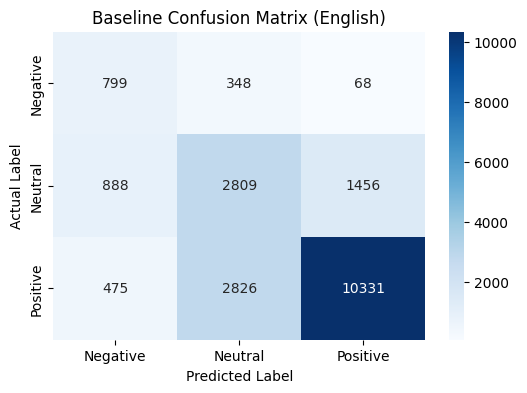

In [ ]:
# Plot the Confusion Matrix for dashboard later
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Baseline Confusion Matrix (English)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV


print("1. Defining the Hyperparameter Grid...")
# We keep the grid focused to respect Colab's compute limits
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000] # Ensure it has enough iterations to converge
}

# 2. Initialize the Base Model
# We keep class_weight='balanced' because of the positive review skew
base_log_reg = LogisticRegression(class_weight='balanced', random_state=42)

# 3. Setup GridSearchCV
# cv=3 means 3-fold cross-validation.
# n_jobs=-1 uses all available CPU cores.
print("2. Initiating GridSearchCV (This will take ~5 to 10 minutes on Colab)...")
grid_search = GridSearchCV(
    estimator=base_log_reg,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1
)

# 4. Fit the Grid Search on our existing TF-IDF training data
grid_search.fit(X_train_tfidf, y_train)

print("\n=== Grid Search Complete ===")
print(f"Best Hyperparameters: {grid_search.best_params_}")

1. Defining the Hyperparameter Grid...
2. Initiating GridSearchCV (This will take ~5 to 10 minutes on Colab)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== Grid Search Complete ===
Best Hyperparameters: {'C': 1.0, 'max_iter': 1000, 'solver': 'liblinear'}



=== Tuned Baseline Model Evaluation (English) ===
              precision    recall  f1-score   support

    Negative       0.45      0.55      0.49      1215
     Neutral       0.56      0.47      0.51      5153
    Positive       0.84      0.87      0.85     13632

    accuracy                           0.75     20000
   macro avg       0.61      0.63      0.62     20000
weighted avg       0.74      0.75      0.74     20000



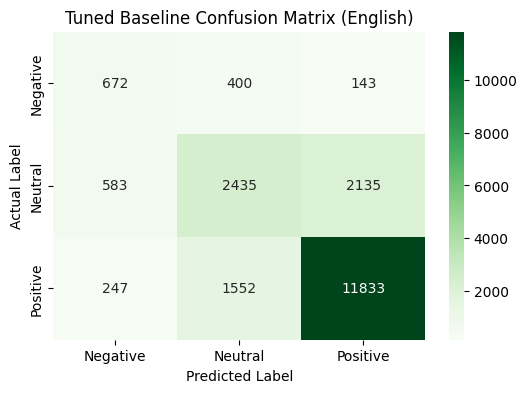

In [ ]:
# 5. Extract the Best Model and Evaluate
best_log_reg = grid_search.best_estimator_
y_pred_tuned = best_log_reg.predict(X_test_tfidf)

print("\n=== Tuned Baseline Model Evaluation (English) ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Negative', 'Neutral', 'Positive']))

# 6. Plot the Tuned Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned, labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Tuned Baseline Confusion Matrix (English)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix


print("1. Loading the Off-the-Shelf Multilingual Transformer...")
# device=0 forces the model onto the GPU for massive acceleration
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    device=0
)

print("2. Extracting cased text for the EXACT same holdout set...")
# We use X_test.index to ensure we test on the exact same 20,000 rows as the baseline
X_test_cased = df_en.loc[X_test.index, 'clean_text'].tolist()

print(f"3. Running GPU Inference on {len(X_test_cased)} rows (This takes ~2-3 minutes)...")
# batch_size=64 pushes multiple rows through the GPU simultaneously
raw_predictions = sentiment_pipeline(X_test_cased, batch_size=64, truncation=True, max_length=512)

# 4. Format the output to match our exact labels ('positive' -> 'Positive')
y_pred_transformer = [pred['label'].capitalize() for pred in raw_predictions]

print("\n=== Phase 4: Off-the-Shelf DistilBERT Evaluation ===")
print(classification_report(y_test, y_pred_transformer, target_names=['Negative', 'Neutral', 'Positive']))

# 5. Plot the Confusion Matrix
cm_trans = confusion_matrix(y_test, y_pred_transformer, labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Off-the-Shelf DistilBERT Confusion Matrix (English)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

1. Loading the Off-the-Shelf Multilingual Transformer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

2. Extracting cased text for the EXACT same holdout set...
3. Running GPU Inference on 20000 rows (This takes ~2-3 minutes)...


## Create a DataFrame comparing the true labels to DistilBERT's predictions

In [ ]:
error_analysis_df = pd.DataFrame({
'text': X_test_cased,
'true_label': y_test.values,
'distilbert_pred': y_pred_transformer
})

Isolate the Misclassifications (Where DistilBERT got it wrong)

In [ ]:
errors = error_analysis_df[error_analysis_df['true_label'] != error_analysis_df['distilbert_pred']]

Define the Niche Domain Vocabulary you mentioned in your resume

In [ ]:
domain_keywords = ['mouthfeel', 'head retention', 'aftertaste', 'skunky', 'lacing', 'carbonation', 'hoppy']

Search the errors for our specific domain words

In [ ]:
print(f"Total DistilBERT Errors: {len(errors)}")
print("Hunting for domain-specific language failures...\n")

for keyword in domain_keywords:
  keyword_errors = errors[errors['text'].str.contains(keyword, case=False, na=False)]
# Find errors that contain the specific keyword (case-insensitive)
if not keyword_errors.empty:
    print(f"=== 🔍 Found {len(keyword_errors)} errors containing '{keyword}' ===")
    # Print one perfect example for your portfolio/interview talking points
    sample = keyword_errors.iloc[0]
    print(f"Review: \"{sample['text'][:200]}...\"")
    print(f"True Label: {sample['true_label']} | Model Guessed: {sample['distilbert_pred']}\n")

Total DistilBERT Errors: 7416
Hunting for domain-specific language failures...

=== 🔍 Found 776 errors containing 'hoppy' ===
Review: "a: hazy brown orange. a little bit of white head, though it dissipates right away. s: not a lot of aroma coming off this guy. maybe a little bready, maybe. there is a little bit of a weird earthy thin..."
True Label: Neutral | Model Guessed: Negative



# Fine Tuning

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

print("1. Preparing Labels for PyTorch...")
# Neural Networks require integer labels!
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df_en['label'] = df_en['sentiment'].map(label_map)

# We use the exact same indexes from Phase 3 to prevent Data Leakage
train_texts = df_en.loc[X_train.index, 'clean_text'].tolist()
train_labels = df_en.loc[X_train.index, 'label'].tolist()

test_texts = df_en.loc[X_test.index, 'clean_text'].tolist()
test_labels = df_en.loc[X_test.index, 'label'].tolist()

# 🚀 ARCHITECTURE TRICK: Slice the training data down to 20K rows.
# This ensures training finishes in ~35 mins on Colab instead of 4 hours.
train_texts = train_texts[:20000]
train_labels = train_labels[:20000]

print(f"Training on {len(train_texts)} rows, Evaluating on {len(test_texts)} holdout rows.")

print("\n2. Loading the Tokenizer...")
model_name = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("3. Tokenizing text (This takes ~1 minute)...")
# max_length=128 captures the core sentiment while saving massive amounts of GPU VRAM
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

print("\n4. Converting to Hugging Face Dataset format...")
class BeverageDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = BeverageDataset(train_encodings, train_labels)
eval_dataset = BeverageDataset(test_encodings, test_labels)

print("\n5. Initializing Model for Domain Adaptation...")
# ignore_mismatched_sizes=True allows us to override the model's default classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

print("\n6. Setting Training Arguments...")
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,              # 2 epochs is perfect for domain adaptation without overfitting
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    fp16=True,                       # 🚀 CRITICAL: Uses Mixed Precision. Speeds up the T4 GPU by 50%!
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

print("\n🔥 Starting Fine-Tuning! Grab a coffee, this will take about 30-45 minutes...")
trainer.train()

1. Preparing Labels for PyTorch...
Training on 20000 rows, Evaluating on 20000 holdout rows.

2. Loading the Tokenizer...
3. Tokenizing text (This takes ~1 minute)...

4. Converting to Hugging Face Dataset format...

5. Initializing Model for Domain Adaptation...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



6. Setting Training Arguments...

🔥 Starting Fine-Tuning! Grab a coffee, this will take about 30-45 minutes...


Epoch,Training Loss,Validation Loss
1,0.606498,0.641622
2,0.576175,0.630058


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.6419943572998047, metrics={'train_runtime': 736.575, 'train_samples_per_second': 54.305, 'train_steps_per_second': 3.394, 'total_flos': 1324697610240000.0, 'train_loss': 0.6419943572998047, 'epoch': 2.0})